In [2]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.7.1+cu118


In [3]:
import sentencepiece as spm
import os
corpus_file = os.getenv('HOME') +'/data/kowiki.txt'
prefix = os.getenv('HOME') + '/work/bert_pretrain/data/ko_8000'
vocab_size = 8000


#센텐스피스를 직접 만들어보실 분들은 주석을 풀어 진행해보세요! 
#(LMS 환경에서는 시간이 오래 걸려요)
#spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")

In [4]:
data_dir = os.getenv('HOME') + '/work/bert_pretrain/data'

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{data_dir}/ko_8000.model")


True

In [254]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


## 데이터 전처리

### (1) Mask 생성

#### masking 구현 함수로 정리

In [5]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### (2) NSP 

#### trim 적용
- token A의 길이가 max_seq보다 길면 앞에서부터 토큰을 제거하고, token B의 길이가 길면 뒤에서부터 토큰을 제거

In [6]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

#### 데이터 셋 구축 함수화

In [7]:

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []  # line 단위 tokens
    current_length = 0
    for i in range(len(doc)): # doc 전체를 loop
        current_chunk.append(doc[i]) # line 단위로 추가
        current_length += len(doc[i]) # current_chunk의 token 수
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq): # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
            
            # token a
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
                
            # token b
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5: # 50% 확률로 swap
                is_next = 0  # False
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1  # True
                
            # max_seq 보다 큰 경우 길이 조절 (trim)
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            # tokens & segment 생성
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # mask
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

### (3) 데이터셋 완성

In [8]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

In [9]:
pretrain_json_path = os.getenv('HOME') + '/work/bert_pretrain/bert_pre_train.json'
corpus_file = os.getenv('HOME') +'/data/kowiki.txt'

#make_pretrain_data(vocab, corpus_file, pretrain_json_path, n_seq = 128)

#### pre-train용 data load 함수

In [10]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename= os.getenv('HOME') + '/work/bert_pretrain/' + 'enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=os.getenv('HOME') + '/work/bert_pretrain/' + 'segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=os.getenv('HOME') + '/work/bert_pretrain/' + 'labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=os.getenv('HOME') + '/work/bert_pretrain/' + 'labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [261]:
pretrain_json_path = os.getenv('HOME') + '/work/bert_pretrain/bert_pre_train.json'

# 128000건만 메모리에 로딩
#pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=None)

  0%|          | 0/918173 [00:00<?, ?it/s]

In [262]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5,   10, 1607, 3599, 1756, 3630,   41, 3644,  830, 3624, 1135,
           52, 3599,   13,   81,   87, 1502, 2247,   25, 3779, 3873, 3667,
         3631, 3813, 3873, 4196, 3636, 3779, 3601,  249, 3725, 1233,   33,
           52, 3599,    6,    6,    6, 6322, 2780,   14, 1510,  168, 3877,
          414,  166, 1697, 4290, 3873, 3703, 3683,  593,   21, 5007,  399,
         1928, 3607,    6,    6,    6,    6,    6,    6,  104, 4313, 4290,
          613, 3638, 3718,   99, 3878, 3656,  256, 2543,  309,  337, 3735,
          181, 3616, 3603,  489,  376, 3599,    4,    6,    6,  207, 3714,
            6, 1042,  104, 3610, 3686, 3718,    6,    6,   37, 3417,  416,
          810, 3666, 3625,  160, 3662,    7, 3629,  203,  241, 3602, 1114,
         3724,  788,  243,    6,    6,    6,  663, 1648, 3682, 3682, 3625,
          203, 3009, 3625, 3616,   16, 3599,    4], dtype=int32),
 memmap([   5,   55, 3674, 3689,    4,   55, 3674, 2149,  356, 4039,  635,
          809, 3665, 2074, 3703, 4

## BERT 모델 구현

In [11]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


In [12]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))



In [13]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_



In [14]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

### Embedding

In [15]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs


In [16]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed



### Attention

In [17]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


In [18]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out

### Position-wise Feed Forward

In [19]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val


### Encoder layer

In [20]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out


### BERT

In [21]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed


### Pre-train BERT

In [22]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        #outputs = F.softmax(outputs, dim=-1)
        return outputs


In [23]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        #outputs_nsp = F.softmax(logits_cls, dim=-1)
        outputs_nsp = logits_cls

        #outputs_mlm = F.softmax(logits_lm, dim=-1)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)


In [24]:
def init_bert_weights(module):
    """
    BERT 모델 가중치 초기화 함수
    """
    if isinstance(module, (nn.Linear, nn.Embedding)):
        # 가중치는 표준편차 0.02인 정규분포로 초기화
        module.weight.data.normal_(mean=0.0, std=0.02)
        # 만약 Linear 레이어에 bias가 있다면 0으로 초기화
        if isinstance(module, nn.Linear) and module.bias is not None:
            module.bias.data.zero_()
            
    elif isinstance(module, nn.LayerNorm):
        # LayerNorm의 bias는 0, weight는 1로 초기화
        module.bias.data.zero_()
        module.weight.data.fill_(1.0)

### 모델 생성

In [58]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 512,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 128,
    "n_vocab": 8000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

## Pre-training

In [26]:
def lm_loss(y_pred, y_true):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)).float(), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float().view(-1)
    #print(mask.shape) #64, 128
    #print(loss.shape) #64*128
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴



In [27]:
def lm_acc(y_pred, y_true):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy



In [28]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        lr = self.get_lr()

        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr
                
        return lr



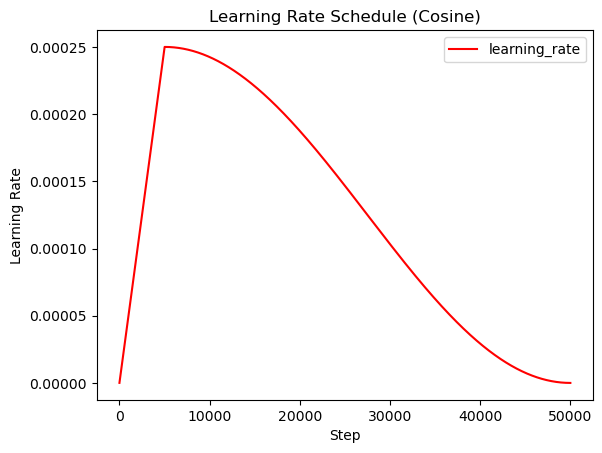

In [281]:
# compute lr
test_schedule = CosineSchedule(optimizer,train_steps=50000, warmup_steps=5000)
#test_schedule =learning_rate_scheduler
lrs = []
for step_num in range(50000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

In [29]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
pre_train_model.apply(init_bert_weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,000
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

#### 변경사항
- scheduler 코드 optimizer 추가
- softmax 함수 삭제하여 cross entropy와의 중복된 연산 삭제
- 가중치 정규분포로 초기화

In [283]:
epochs = 20
batch_size = 256

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)

optimizer = optim.AdamW(pre_train_model.parameters())
learning_rate_scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=max(100, train_steps // 5), max_lr=5.0e-3)

loss_fn_nsp = nn.CrossEntropyLoss()

train_steps: 71740


In [ ]:
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

pre_train_inputs_g = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels_g = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs_g[0], pre_train_inputs_g[1], pre_train_labels_g[0], pre_train_labels_g[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

save_dir = os.getenv('HOME') + '/work/bert_pretrain/models'

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        
        #loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        loss_mlm = lm_loss(logits_mlm, labels_mlm_batch)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()

        learning_rate_scheduler.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        #mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()
        mlm_acc = lm_acc(logits_mlm, labels_mlm_batch)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{save_dir}/large_lr_bert_pre_train_epoch_{epoch+1}.pt")
    
with open(save_dir + '/large_lr_bert_model_history.pickle','wb') as fw:
    pickle.dump(history, fw)

Epoch 1/20 - Loss: 14.701153551265993, NSP Loss: 0.41971860634506264, MLM Loss: 14.281434942893673, NSP Accuracy: 0.7414686824074355, MLM Accuracy: 0.13955566717105586
Epoch 2/20 - Loss: 10.734145497092637, NSP Loss: 0.3719616050520148, MLM Loss: 10.362183891500575, NSP Accuracy: 0.7582537053287411, MLM Accuracy: 0.2522285253033852


In [52]:
print('max nsp acc: ', max(history['nsp_acc']))
print('max mlm_acc: ', max(history['mlm_acc']))

max nsp acc:  0.793625
max mlm_acc:  0.32128659790754316


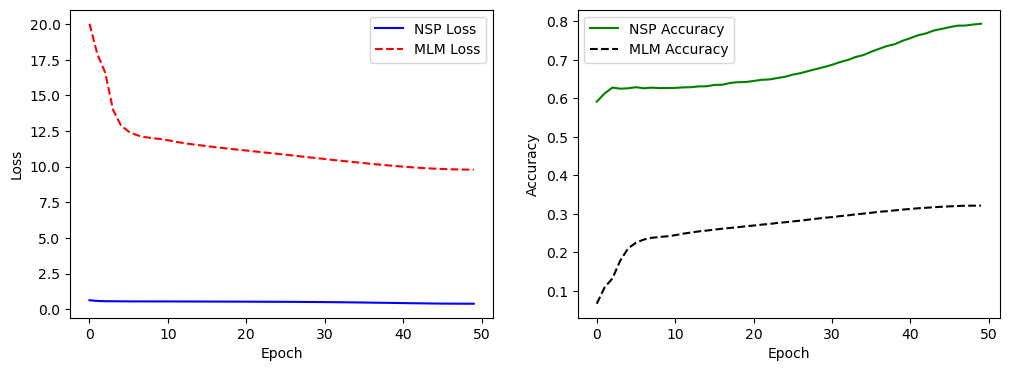

In [50]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

- 학습 그래프를 살펴본 결과 epoch이 늘어남에 따라 loss는 감소하고, accuracy가 증가하는 모습을 보였다.
- NSP와 MLM task는 각각 79.36%, 32.13%정확도를 달성했다.

## 정성적 평가
- zero-shot 방식을 통해 정성적 평가를 실시하였다.
- BERT 모델이 pre-training 과정을 통해 언어의 특징과 표현을 잘 학습했는지 판단하기 위해 '사실 지식', 'Topic 분류', '상식 추론' 위 세 가지 능력을 확인한다.
- 위에서 언급한 세 가지 능력 중 하나를 보유해야만 예측할 수 있는 token을 mask token으로 대체하여 예측하도록 한다.
- 각 능력에 대한 test sample을 마련하여 평가한다.

### zero-shot 

In [37]:
data_dir = os.getenv('HOME') + '/work/bert_pretrain/data'

# vocab loading
sp_vocab = spm.SentencePieceProcessor()
sp_vocab.load(f"{data_dir}/ko_8000.model")


True

In [39]:
# 모델 load
pre_train_model_L = build_model_pre_train(config)
pre_train_model_L.load_state_dict(torch.load(save_dir+'/large_lr_bert_pre_train_epoch_10.pt'))
pre_train_model_L.to(device)

PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(128, 128)
    )
    (segment): Embedding(2, 128)
    (norm): LayerNorm((128,), eps=0.001, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=128, out_features=256, bias=True)
          (W_K): Linear(in_features=128, out_features=256, bias=True)
          (W_V): Linear(in_features=128, out_features=256, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=0.001, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=128, out_features=512, bias=True)
          (W_2): Linear(in_features=512, out_features=128, bias=True)
          (gelu): GELU(approximate='none')
        )


In [35]:
def zero_shot_test(test_input_a, test_input_b, model, sp_vocab):
    # 각 문장 별 piece 단위로 분리
    tokens_a = sp_vocab.encode_as_pieces(test_input_a)
    tokens_b = sp_vocab.encode_as_pieces(test_input_b)

    # 토큰화
    test_tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    test_ids = [sp_vocab.piece_to_id(p) for p in test_tokens]
    
    # segment 입력 
    test_segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    
    # mask 토큰 위치 저장
    mask_idx = test_ids.index(6)
    
    test_ids = torch.tensor([test_ids], dtype=torch.long, device=device)
    test_segment = torch.tensor([test_segment], dtype=torch.long, device=device)
    
    # mask 토큰 predict
    model.eval()
    with torch.no_grad():
        _, test_logits_mlm = model(test_ids, test_segment)
    
    y_test_pred = torch.argmax(test_logits_mlm, dim=-1)
    mask_pred = sp_vocab.id_to_piece(y_test_pred[0][mask_idx].item())
    
    print('****************************************')
    print("입력 문장: ", " ".join(test_tokens))
    print("[MASK] 토큰 예측: ", mask_pred)
    print('****************************************')

### 사실 지식

In [40]:
test_input_a_list = ['태양계에는 여러 행성이 존재한다.' , '전화기는 인류의 중요한 발명품이다.', '피카소는 20세기 미술에 큰 영향을 준 화가이다.']
test_input_b_list = ['태양계에서 가장 큰 행성은 [MASK]이다.' , '전화기를 발명한 사람은 [MASK]이다.', '피카소는 [MASK] 출신 화가이다.']

for test_input_a, test_input_b in zip(test_input_a_list, test_input_b_list):
    zero_shot_test(test_input_a, test_input_b, pre_train_model_L, sp_vocab)

****************************************
입력 문장:  [CLS] ▁태양 계 에는 ▁여러 ▁행 성이 ▁존재한다 . [SEP] ▁태양 계에서 ▁가장 ▁큰 ▁행 성은 ▁ [MASK] 이다 . [SEP]
[MASK] 토큰 예측:  ▁둘
****************************************
****************************************
입력 문장:  [CLS] ▁전 화 기는 ▁인 류의 ▁중요한 ▁발 명 품 이다 . [SEP] ▁전 화 기를 ▁발 명한 ▁사람은 ▁ [MASK] 이다 . [SEP]
[MASK] 토큰 예측:  ▁또는
****************************************
****************************************
입력 문장:  [CLS] ▁피 카 소는 ▁20 세기 ▁미술 에 ▁큰 ▁영향을 ▁준 ▁화 가이다 . [SEP] ▁피 카 소는 ▁ [MASK] ▁출신 ▁화 가이다 . [SEP]
[MASK] 토큰 예측:  ▁독일
****************************************


### Topic 분류

In [41]:
test_input_a_list = ['어제 열린 경기에서 한국 대표팀이 두 골을 넣어 승리했다.' , '정부가 새로운 세금 정책을 발표했다.', '새로운 스마트폰이 출시되며 인공지능 기능이 크게 향상되었다.']
test_input_b_list = ['이 기사는 [MASK]에 관한 내용이다.' , '이 기사는 [MASK]에 관한 이야기이다.', '이 기사는 [MASK]에 관한 내용이다.']

for test_input_a, test_input_b in zip(test_input_a_list, test_input_b_list):
    zero_shot_test(test_input_a, test_input_b, pre_train_model_L, sp_vocab)

****************************************
입력 문장:  [CLS] ▁어 제 ▁열린 ▁경기에서 ▁한국 ▁대표 팀 이 ▁두 ▁골 을 ▁넣 어 ▁승리 했다 . [SEP] ▁이 ▁기 사는 ▁ [MASK] 에 ▁관한 ▁내용 이다 . [SEP]
[MASK] 토큰 예측:  에
****************************************
****************************************
입력 문장:  [CLS] ▁정부 가 ▁새로운 ▁세 금 ▁정책 을 ▁발표했다 . [SEP] ▁이 ▁기 사는 ▁ [MASK] 에 ▁관한 ▁이야기 이다 . [SEP]
[MASK] 토큰 예측:  ▁및
****************************************
****************************************
입력 문장:  [CLS] ▁새로운 ▁스 마 트 폰 이 ▁출시 되며 ▁인 공 지 능 ▁기능 이 ▁크게 ▁향 상 되었다 . [SEP] ▁이 ▁기 사는 ▁ [MASK] 에 ▁관한 ▁내용 이다 . [SEP]
[MASK] 토큰 예측:  에
****************************************


### 상식 추론

In [42]:
test_input_a_list = ['많은 사람들이 아침에 잠에서 깨어난다.', '겨울에는 기온이 낮아진다.', '사람은 어두운 곳에서 잘 보이지 않는다.']
test_input_b_list = ['그래서 사람들은 보통 아침에 [MASK]를 마신다.', '그래서 사람들은 [MASK]을 입는다.', '그래서 사람들은 밤에 [MASK]을 켠다.']

for test_input_a, test_input_b in zip(test_input_a_list, test_input_b_list):
    zero_shot_test(test_input_a, test_input_b, pre_train_model_L, sp_vocab)

****************************************
입력 문장:  [CLS] ▁많은 ▁사람들이 ▁아 침 에 ▁잠 에서 ▁깨 어 난다 . [SEP] ▁그래서 ▁사람들은 ▁보통 ▁아 침 에 ▁ [MASK] 를 ▁마 신 다 . [SEP]
[MASK] 토큰 예측:  ▁또는
****************************************
****************************************
입력 문장:  [CLS] ▁겨울 에는 ▁기 온 이 ▁낮 아 진다 . [SEP] ▁그래서 ▁사람들은 ▁ [MASK] 을 ▁입 는다 . [SEP]
[MASK] 토큰 예측:  ▁겨울
****************************************
****************************************
입력 문장:  [CLS] ▁사람은 ▁어 두 운 ▁곳 에서 ▁잘 ▁보 이지 ▁않는다 . [SEP] ▁그래서 ▁사람들은 ▁밤 에 ▁ [MASK] 을 ▁ 켠 다 . [SEP]
[MASK] 토큰 예측:  ▁말을
****************************************


- 사실 지식, topic 분류, 상식 추론 모두에서 mask token을 정확히 예측했다고 볼 수 없기에 언어적 특성과 표현을 잘 학습했다고 보기 어렵다.
